# Cleaning of DataSet

We perform the cleaning of Auto Dataset 1985 and perform the elementary **EDA** and cluster the data using **K-means** . Interested members can perform further analysis using the cleaned dataset. 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cleaned-auto-dataset-1985/auto_clean_1985_dataset.csv
/kaggle/input/cleaned-auto-dataset-1985/auto_raw_data.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

Lets read the data.

In [3]:
df = pd.read_csv('/kaggle/input/cleaned-auto-dataset-1985/auto_raw_data.csv',header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


Lets  check each of the column and it is found that no column is provided with the names.

So now lets name each of the column accordingly.

In [4]:
column_names = ['symboling','normalized_losses', 'CarName','fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation',
               'wheelbase','carlength','carwidth','carheight','curbweight','enginetype','cylindernumber','enginesize','fuelsystem',
               'boreratio','stroke','compressionratio','horsepower','peakrpm','citympg','highwaympg','price'] # Its better to have domain knowledge before naming the columns.
df.columns = column_names
df.head()

,symboling,normalized_losses,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


Now lets check data each of the column and find if there are any NULL values or "Rubbish" data to be reomved before we proceed with the descriptive analysis.

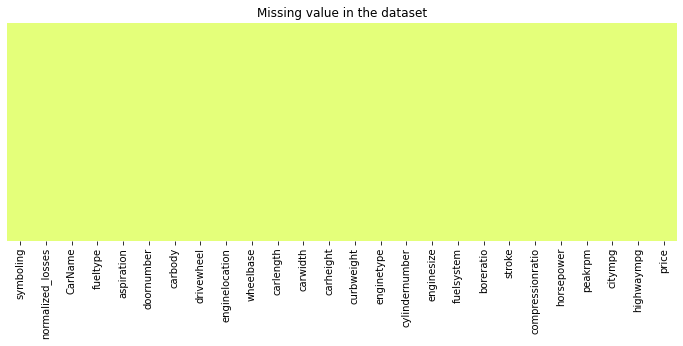

In [5]:
#check missing values
plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(),cbar=False,cmap='Wistia',yticklabels=False)
plt.title('Missing value in the dataset');

There is no null data in any of the columns. But there is some rubbish data. We will identify and clean it. 

So there is no NULL data in any of the columns.

Lets check for "Rubbish" data by checking unique values for each column and replacing the rubbish data with the mean data if the data is numerical and normally distributed. If it is skewed we replace it with Median value. If the data is categorical we replace it with the mode values. We can even remove the records if the rubbish data accounts to less than 0.5% records of the total data.

lets check for "normalized_losses" column, it is found that 20% of the data is rubbish.

A small code to identify the rubbish data in each column. And, impute it with appropriate values.

In [6]:
def removenotnum(list1):
 notnum = []

 for x in list1:
   try:
     float(x)
     
   except:
     notnum.append(x)
 return notnum

notnumtable = removenotnum(df['normalized_losses'])
print(notnumtable)
print('Percent of identified rubbish data in Table → {:.3f}%'.format(len(notnumtable) / len(df['normalized_losses'])*100))

['?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?']
Percent of identified rubbish data in Table → 20.000%


So we replace the '?' value with either mean or median of the other column values depending upon the distribution.

Before we go in, we will make an array of remaining values of the column to find the distribution and mean & median of the remaining data.

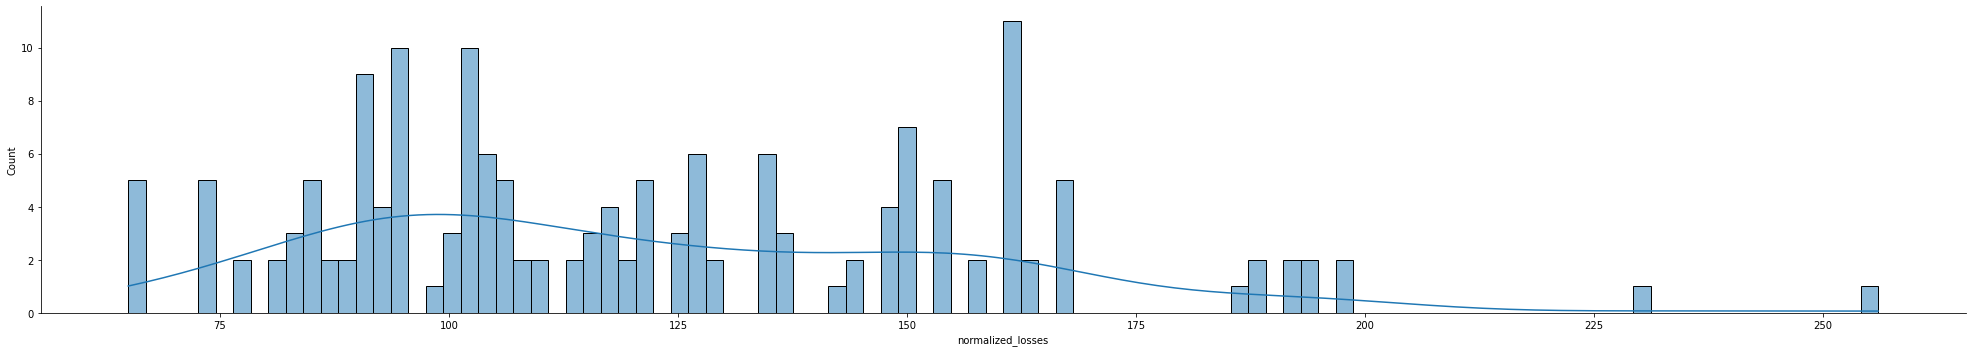

In [7]:
rubbish=['?']
n_l = df['normalized_losses'][~df['normalized_losses'].isin(rubbish)]
n_l = n_l.astype('int64')
sns.displot(x=n_l, kind="hist",kde=True, bins = 100, aspect = 5.5)

It is found that the data is positive skewed so we replace the data with the "Median value".

In [8]:
print('median:{}'.format(n_l.median()))

median:115.0


So we replace the value with 115

In [9]:
df['normalized_losses'].replace({'?':'115'}, inplace=True)

Similarly for the "doornumber" column which is categorical we found rubbish data and replace it with "Mode" of the column. 

Similarly for "boreratio" , "stroke", "horsepower", "price" and "peakrpm" columns, we follow the same procedure as done for the "normalized_losses" column as mentioned above.

Now all the rubbish data is replaced with the respective mean, median and mode. We will replace few categorical columns with OHE (one hot encoding).


In [10]:
df['doornumber'].unique()

array(['two', 'four', '?'], dtype=object)

In [11]:
len(df[df['doornumber'] == '?'])

2

In [12]:
rubbish=['?']
d_n = df['doornumber'][~df['doornumber'].isin(rubbish)]

print('mode:{}'.format(d_n.mode()))
df['doornumber'].replace({'?':'four'}, inplace=True)

mode:0    four
dtype: object


In [13]:
df['carbody'].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [14]:
df['drivewheel'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [15]:
df['enginelocation'].unique()

array(['front', 'rear'], dtype=object)

In [16]:
df['enginetype'].unique()

array(['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv'], dtype=object)

In [17]:
df['cylindernumber'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [18]:
df['fuelsystem'].unique()

array(['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', '4bbl', 'idi', 'spdi'],
      dtype=object)

In [19]:
df['boreratio'].unique()

array(['3.47', '2.68', '3.19', '3.13', '3.50', '3.31', '3.62', '2.91',
       '3.03', '2.97', '3.34', '3.60', '2.92', '3.15', '3.43', '3.63',
       '3.54', '3.08', '?', '3.39', '3.76', '3.58', '3.46', '3.80',
       '3.78', '3.17', '3.35', '3.59', '2.99', '3.33', '3.70', '3.61',
       '3.94', '3.74', '2.54', '3.05', '3.27', '3.24', '3.01'],
      dtype=object)

In [20]:
df['stroke'].unique()

array(['2.68', '3.47', '3.40', '2.80', '3.19', '3.39', '3.03', '3.11',
       '3.23', '3.46', '3.90', '3.41', '3.07', '3.58', '4.17', '2.76',
       '3.15', '?', '3.16', '3.64', '3.10', '3.35', '3.12', '3.86',
       '3.29', '3.27', '3.52', '2.19', '3.21', '2.90', '2.07', '2.36',
       '2.64', '3.08', '3.50', '3.54', '2.87'], dtype=object)

In [21]:
def removenotnum(list1):
 notnum = []

 for x in list1:
   try:
     float(x)
     
   except:
     notnum.append(x)
 return notnum

notnumtable = removenotnum(df['boreratio'])
print(notnumtable)
print('Percent of identified rubbish data in Table → {:.3f}%'.format(len(notnumtable) / len(df['boreratio'])*100))


['?', '?', '?', '?']
Percent of identified rubbish data in Table → 1.951%


In [22]:
rubbish=['?']
b_r = df['boreratio'][~df['boreratio'].isin(rubbish)]
b_r = b_r.astype('float64')


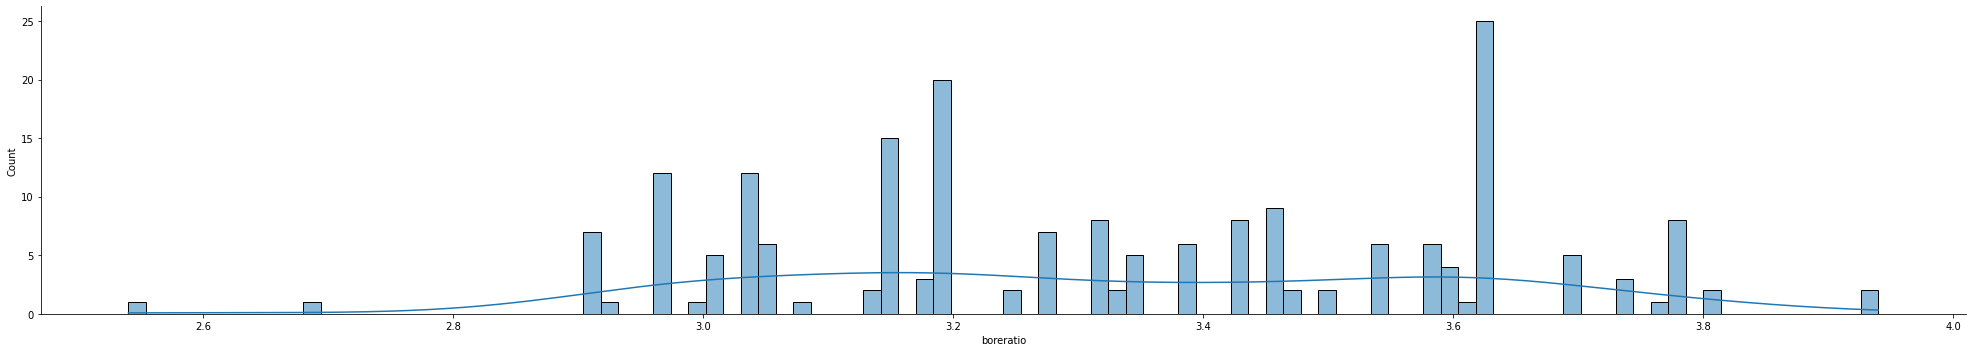

In [23]:
sns.displot(x=b_r, kind="hist",kde=True, bins = 100, aspect = 5.5)

In [24]:
print('mean:{}'.format(b_r.mean()))
print('median:{}'.format(b_r.median()))
print('mode:{}'.format(b_r.mode()))

mean:3.3297512437810957
median:3.31
mode:0    3.62
dtype: float64


In [25]:
df['boreratio'].replace({'?':'3.31'}, inplace=True)
df['boreratio']=df['boreratio'].astype('float64')

In [26]:
def removenotnum(list1):
 notnum = []

 for x in list1:
   try:
     float(x)
     
   except:
     notnum.append(x)
 return notnum

notnumtable = removenotnum(df['stroke'])
print(notnumtable)
print('Percent of identified rubbish data in Table → {:.3f}%'.format(len(notnumtable) / len(df['stroke'])*100))


['?', '?', '?', '?']
Percent of identified rubbish data in Table → 1.951%


In [27]:
rubbish=['?']
s_t = df['stroke'][~df['stroke'].isin(rubbish)]
s_t = s_t.astype('float64')


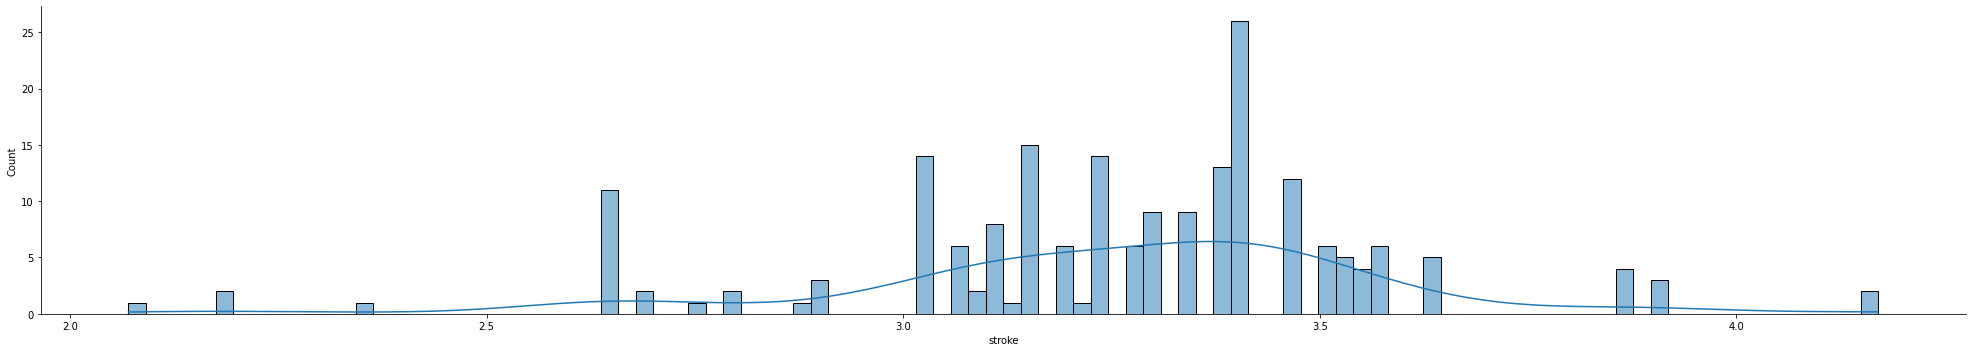

In [28]:
sns.displot(x=s_t, kind="hist",kde=True, bins = 100, aspect = 5.5)

In [29]:
print('mean:{}'.format(s_t.mean()))
print('median:{}'.format(s_t.median()))
print('mode:{}'.format(s_t.mode()))

mean:3.2554228855721337
median:3.29
mode:0    3.4
dtype: float64


In [30]:
df['stroke'].replace({'?':'3.29'}, inplace=True)
df['stroke']=df['stroke'].astype('float64')

In [31]:
df['horsepower'].unique()

array(['111', '154', '102', '115', '110', '140', '160', '101', '121',
       '182', '48', '70', '68', '88', '145', '58', '76', '60', '86',
       '100', '78', '90', '176', '262', '135', '84', '64', '120', '72',
       '123', '155', '184', '175', '116', '69', '55', '97', '152', '200',
       '95', '142', '143', '207', '288', '?', '73', '82', '94', '62',
       '56', '112', '92', '161', '156', '52', '85', '114', '162', '134',
       '106'], dtype=object)

In [32]:
def removenotnum(list1):
 notnum = []

 for x in list1:
   try:
     float(x)
     
   except:
     notnum.append(x)
 return notnum

notnumtable = removenotnum(df['horsepower'])
print(notnumtable)
print('Percent of identified rubbish data in Table → {:.3f}%'.format(len(notnumtable) / len(df['horsepower'])*100))


['?', '?']
Percent of identified rubbish data in Table → 0.976%


In [33]:
rubbish=['?']
h_p = df['horsepower'][~df['horsepower'].isin(rubbish)]
h_p = h_p.astype('int64')


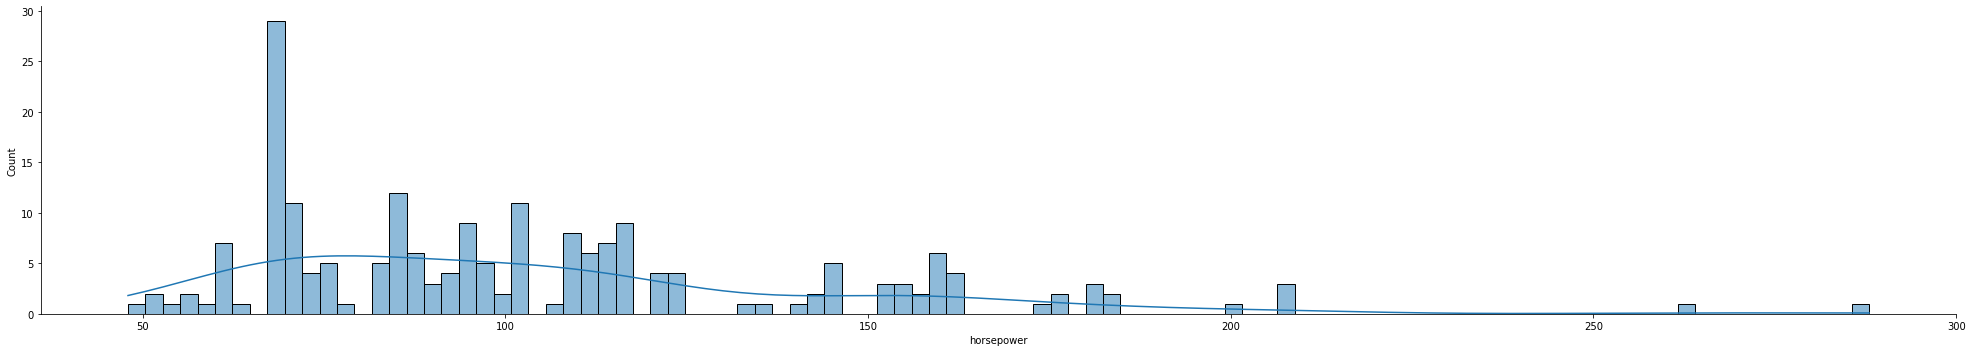

In [34]:
sns.displot(x=h_p, kind="hist",kde=True, bins = 100, aspect = 5.5)

In [35]:
print('mean:{}'.format(h_p.mean()))
print('median:{}'.format(h_p.median()))
print('mode:{}'.format(h_p.mode()))

mean:104.25615763546799
median:95.0
mode:0    68
dtype: int64


In [36]:
df['horsepower'].replace({'?':'95'}, inplace=True)
df['horsepower']=df['horsepower'].astype('int64')

In [37]:
df['peakrpm'].unique()

array(['5000', '5500', '5800', '4250', '5400', '5100', '4800', '6000',
       '4750', '4650', '4200', '4350', '4500', '5200', '4150', '5600',
       '5900', '5750', '?', '5250', '4900', '4400', '6600', '5300'],
      dtype=object)

In [38]:
def removenotnum(list1):
 notnum = []

 for x in list1:
   try:
     float(x)
     
   except:
     notnum.append(x)
 return notnum

notnumtable = removenotnum(df['peakrpm'])
print(notnumtable)
print('Percent of identified rubbish data in Table → {:.3f}%'.format(len(notnumtable) / len(df['peakrpm'])*100))


['?', '?']
Percent of identified rubbish data in Table → 0.976%


In [39]:
rubbish=['?']
p_r = df['peakrpm'][~df['peakrpm'].isin(rubbish)]
p_r = p_r.astype('int64')


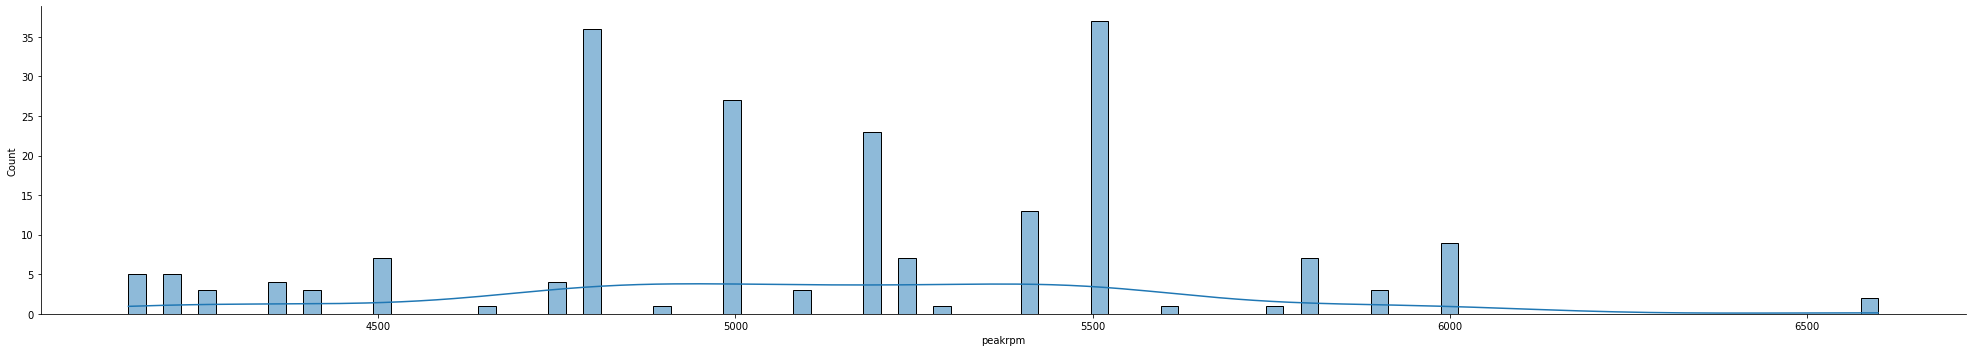

In [40]:
sns.displot(x=p_r, kind="hist",kde=True, bins = 100, aspect = 5.5)

In [41]:
print('mean:{}'.format(p_r.mean()))
print('median:{}'.format(p_r.median()))
print('mode:{}'.format(p_r.mode()))

mean:5125.369458128079
median:5200.0
mode:0    5500
dtype: int64


In [42]:
df['peakrpm'].replace({'?':'5200'}, inplace=True)
df['peakrpm']=df['peakrpm'].astype('int64')

In [43]:
def removenotnum(list1):
 notnum = []

 for x in list1:
   try:
     float(x)
     
   except:
     notnum.append(x)
 return notnum

notnumtable = removenotnum(df['price'])
print(notnumtable)
print('Percent of identified rubbish data in Table → {:.3f}%'.format(len(notnumtable) / len(df['price'])*100))


['?', '?', '?', '?']
Percent of identified rubbish data in Table → 1.951%


In [44]:
rubbish=['?']
pr = df['price'][~df['price'].isin(rubbish)]
pr = pr.astype('int64')


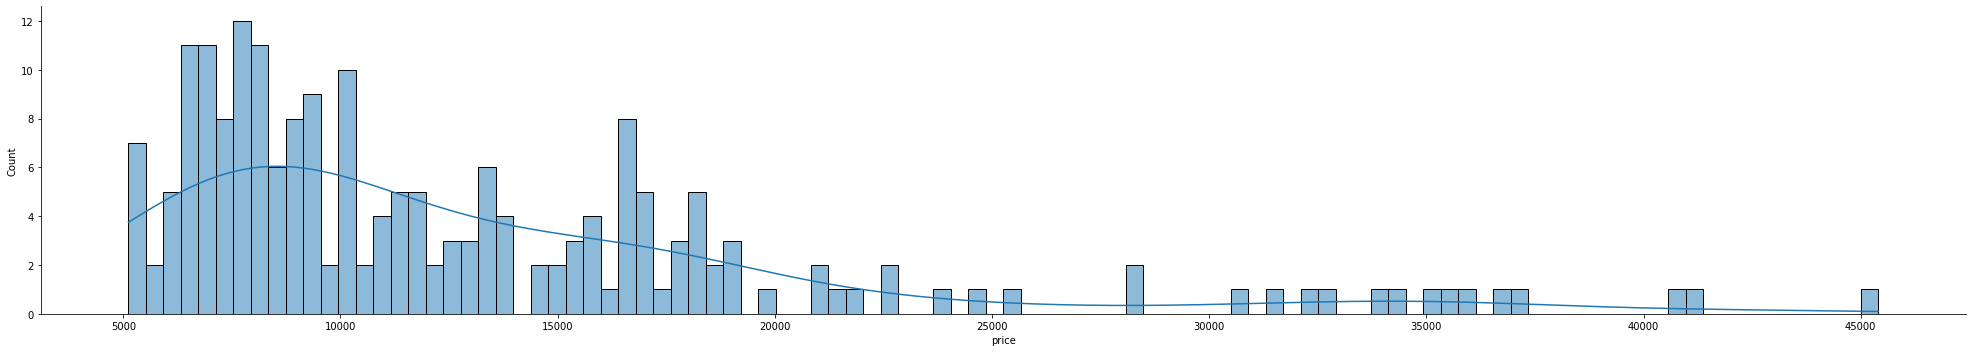

In [45]:
sns.displot(x=pr, kind="hist",kde=True, bins = 100, aspect = 5.5)

In [46]:
print('mean:{}'.format(pr.mean()))
print('median:{}'.format(pr.median()))
print('mode:{}'.format(pr.mode()))

mean:13207.129353233831
median:10295.0
mode:0      5572
1      6229
2      6692
3      7295
4      7609
5      7775
6      7898
7      7957
8      8495
9      8845
10     8921
11     9279
12    13499
13    16500
14    18150
dtype: int64


In [47]:
df['price'].replace({'?':'10295'}, inplace=True)
df['price']=df['price'].astype('int64')

In [48]:
df['price'].unique()

array([13495, 16500, 13950, 17450, 15250, 17710, 18920, 23875, 10295,
       16430, 16925, 20970, 21105, 24565, 30760, 41315, 36880,  5151,
        6295,  6575,  5572,  6377,  7957,  6229,  6692,  7609,  8558,
        8921, 12964,  6479,  6855,  5399,  6529,  7129,  7295,  7895,
        9095,  8845, 12945, 10345,  6785, 11048, 32250, 35550, 36000,
        5195,  6095,  6795,  6695,  7395, 10945, 11845, 13645, 15645,
        8495, 10595, 10245, 10795, 11245, 18280, 18344, 25552, 28248,
       28176, 31600, 34184, 35056, 40960, 45400, 16503,  5389,  6189,
        6669,  7689,  9959,  8499, 12629, 14869, 14489,  6989,  8189,
        9279,  5499,  7099,  6649,  6849,  7349,  7299,  7799,  7499,
        7999,  8249,  8949,  9549, 13499, 14399, 17199, 19699, 18399,
       11900, 13200, 12440, 13860, 15580, 16900, 16695, 17075, 16630,
       17950, 18150, 12764, 22018, 32528, 34028, 37028,  9295,  9895,
       11850, 12170, 15040, 15510, 18620,  5118,  7053,  7603,  7126,
        7775,  9960,

We will change "symboling" and "CarName" column as type category. As we dont want to perform the OHE on them.

In [49]:
df['symboling'] = df.symboling.astype('category')
df['CarName'] = df.CarName.astype('category')
df.normalized_losses=df.normalized_losses.astype('int64')
df.dtypes

symboling            category
normalized_losses       int64
CarName              category
fueltype               object
aspiration             object
doornumber             object
carbody                object
drivewheel             object
enginelocation         object
wheelbase             float64
carlength             float64
carwidth              float64
carheight             float64
curbweight              int64
enginetype             object
cylindernumber         object
enginesize              int64
fuelsystem             object
boreratio             float64
stroke                float64
compressionratio      float64
horsepower              int64
peakrpm                 int64
citympg                 int64
highwaympg              int64
price                   int64
dtype: object

Now lets perform the OHE only on the columns with type "object". 

So we collect the columns with dtype object.

# Elementary Exploratory Data Analysis

<AxesSubplot:ylabel='CarName'>

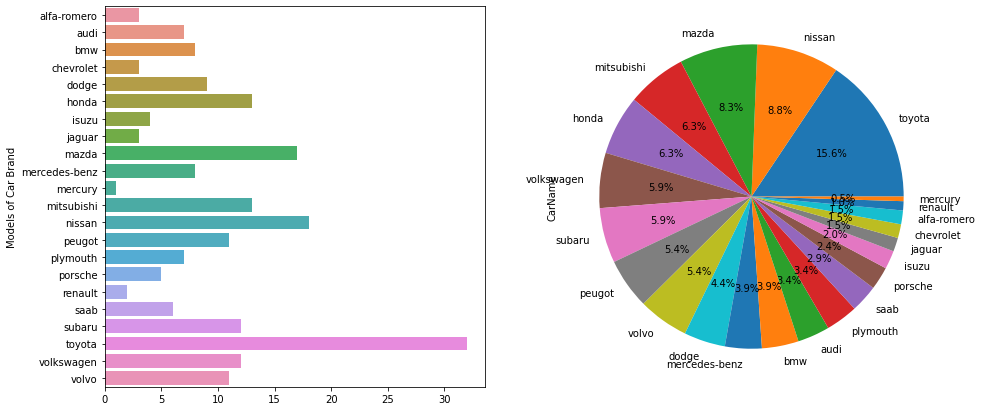

In [50]:
target_counts= df['CarName'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(y = target_counts.index,x = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Models of Car Brand')
ax[0].set_facecolor('white')
#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])

Text(0.5, 0.98, 'Fuel Type')

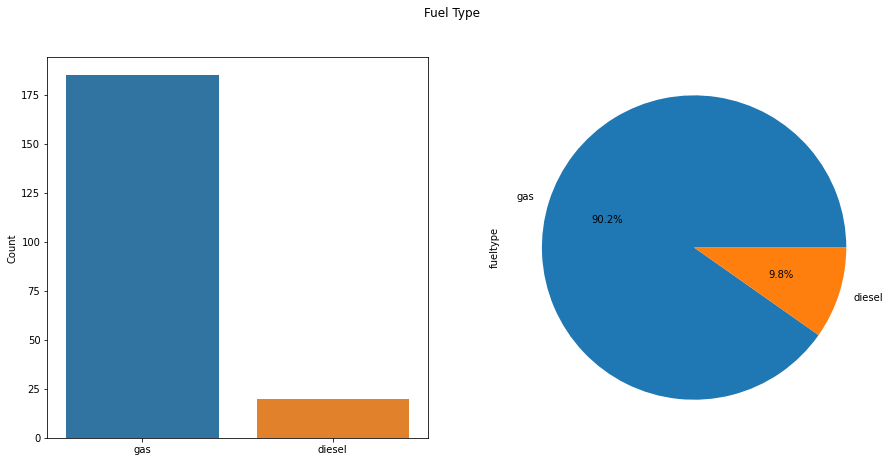

In [51]:
target_counts= df['fueltype'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])
fig.suptitle('Fuel Type')

Text(0.5, 0.98, 'Aspiration')

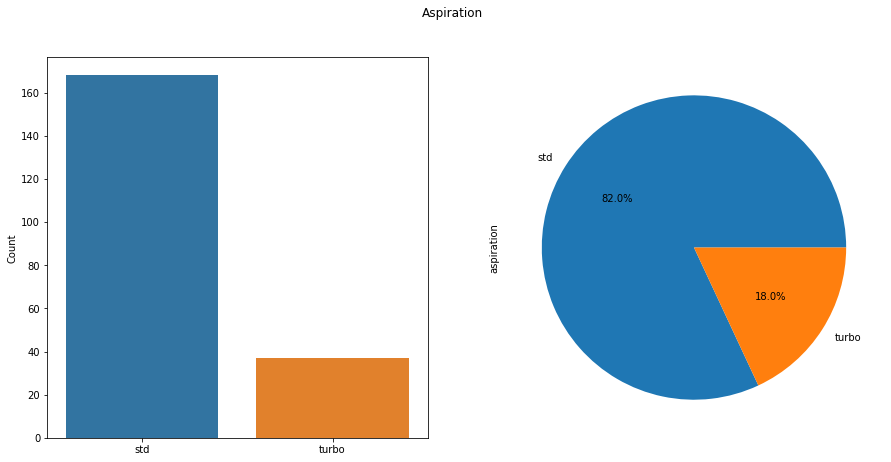

In [52]:
target_counts= df['aspiration'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])
                                
fig.suptitle('Aspiration')

Text(0.5, 0.98, 'Number of Doors')

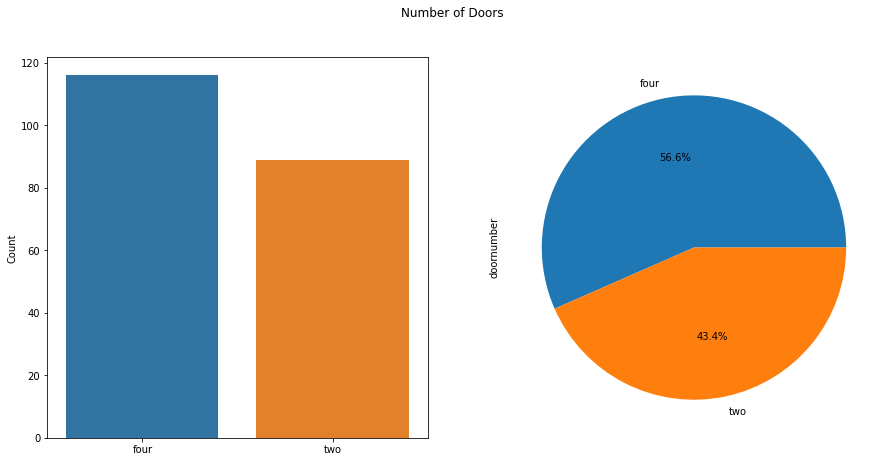

In [53]:
target_counts= df['doornumber'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])
fig.suptitle('Number of Doors')

Text(0.5, 0.98, 'Body Type')

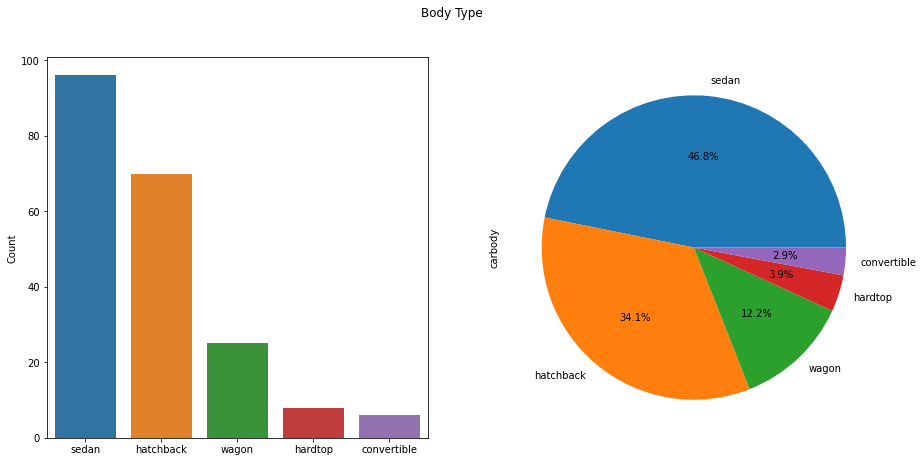

In [54]:
target_counts= df['carbody'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])
fig.suptitle('Body Type')

Text(0.5, 0.98, 'Drive Wheel')

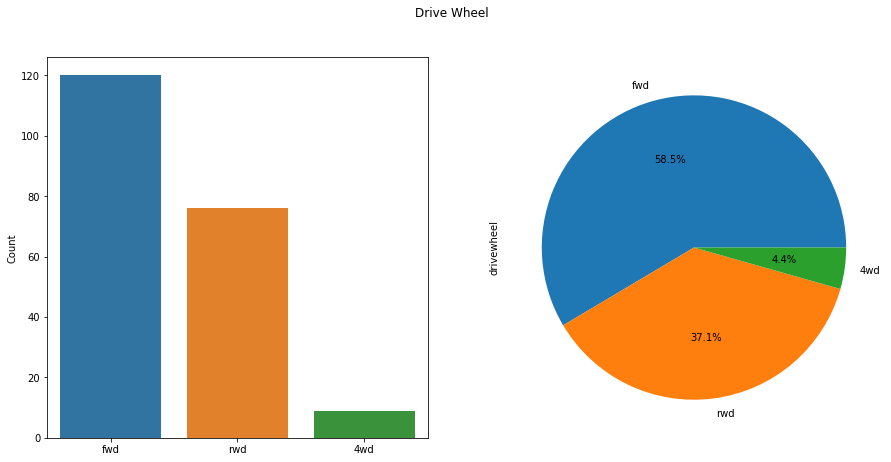

In [55]:
target_counts= df['drivewheel'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])
fig.suptitle('Drive Wheel')

Text(0.5, 0.98, 'Engine Location')

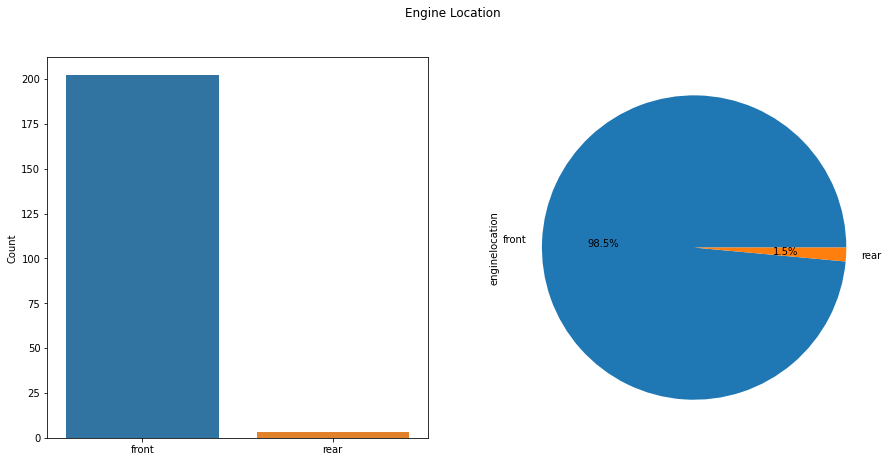

In [56]:
target_counts= df['enginelocation'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])
fig.suptitle('Engine Location')

Text(0.5, 0.98, 'Engine Type')

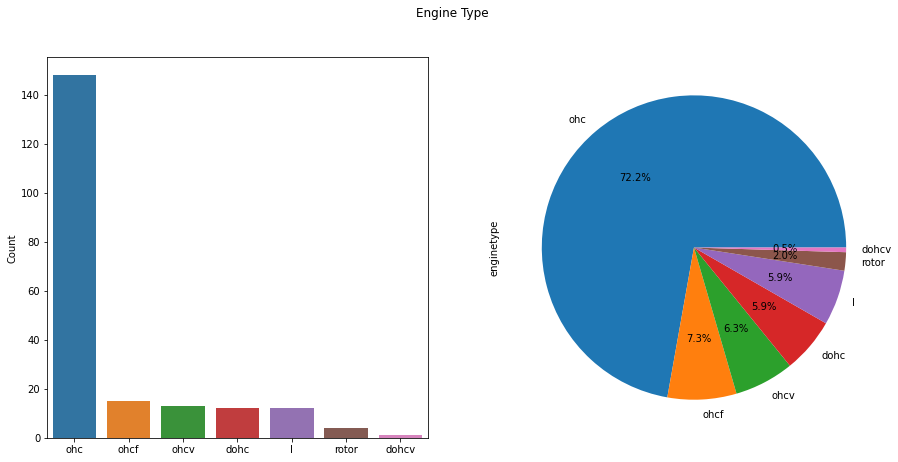

In [57]:
target_counts= df['enginetype'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", ax=ax[1])
fig.suptitle('Engine Type')

Text(0.5, 0.98, 'Number of Cylinders')

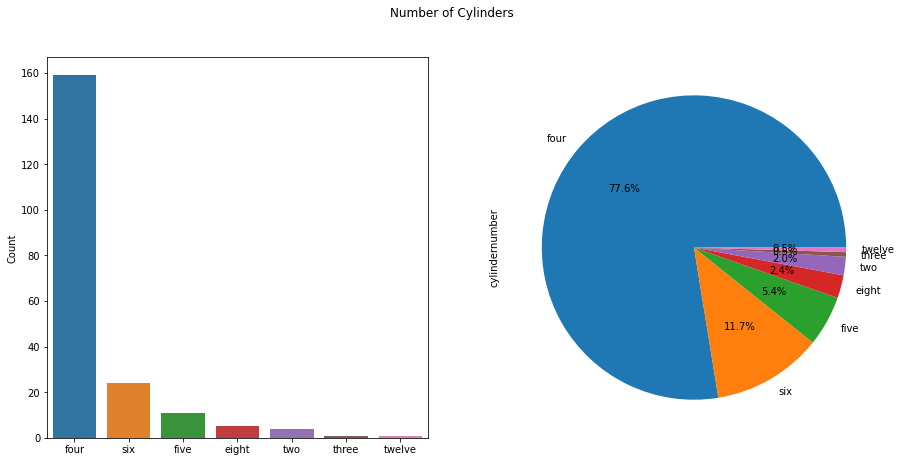

In [58]:
target_counts= df['cylindernumber'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%", pctdistance=0.6, ax=ax[1])
fig.suptitle('Number of Cylinders')

Text(0.5, 0.98, 'Fuel System')

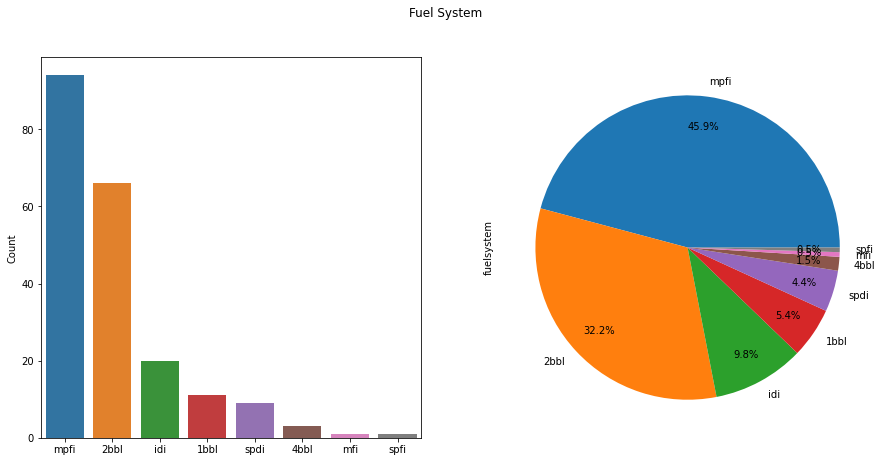

In [59]:
target_counts= df['fuelsystem'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15,7))
target_counts_barplot = sns.barplot(x = target_counts.index,y = target_counts.values, ax = ax[0])
target_counts_barplot.set_ylabel('Count')

#colors = ['#8d99ae','#ffe066', '#f77f00','#348aa7','#bce784','#ffcc99',  '#f25f5c']
target_counts.plot.pie(autopct="%1.1f%%",pctdistance=0.8, ax=ax[1])
fig.suptitle('Fuel System')

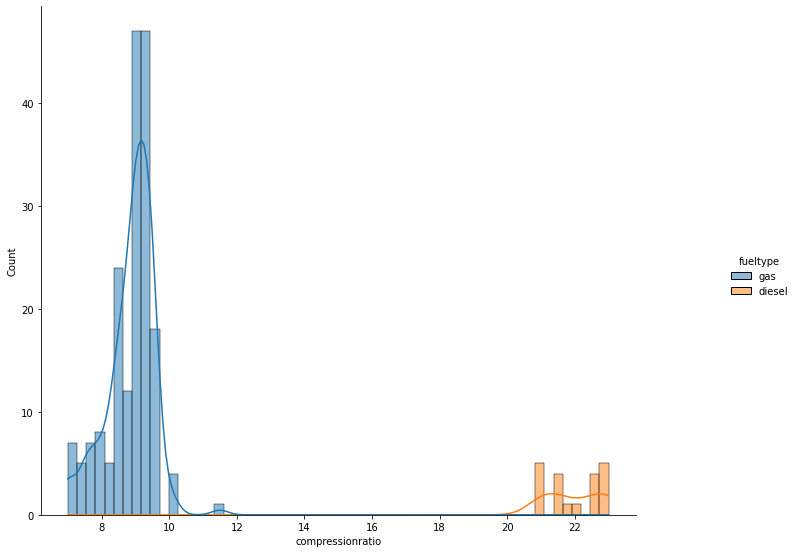

In [60]:
sns.displot(df, x="compressionratio", hue='fueltype',kde=True)
plt.gcf().set_size_inches(11.7, 8.27)

Looking from the data compression ratio is easily classified depending upon the fueltype. So we can remove either of one column to progress with our analysis.

Only numerical data distribution and linear and polynomial regression of order 4 is considered to look at the distribution of data.

The green line represents the linear regression line and the red line represents the polynomial fit of order 4 and with confidence interval of 90%.

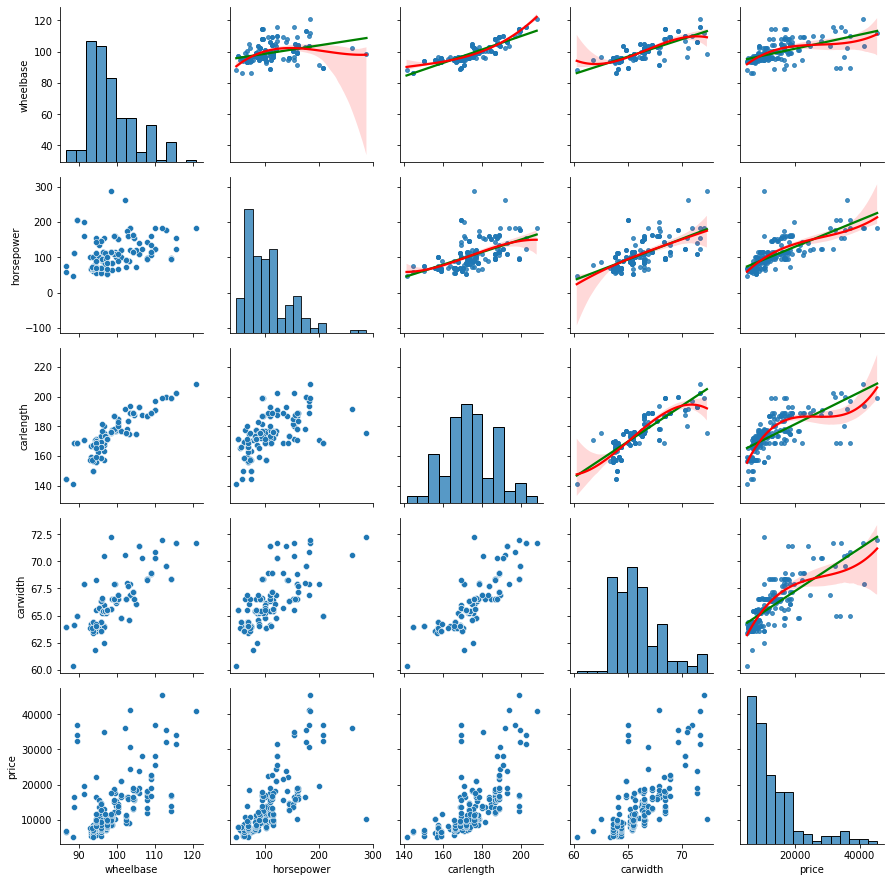

In [61]:
g=sns.PairGrid(data = df,vars = ['wheelbase','horsepower','carlength','carwidth','price'])
g.map_upper(sns.regplot,ci=None, scatter_kws={'s':15}, line_kws={"color": "green"})
g.map_upper(sns.regplot,ci=90,line_kws={"color": "red"},order=3,scatter=False)
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)

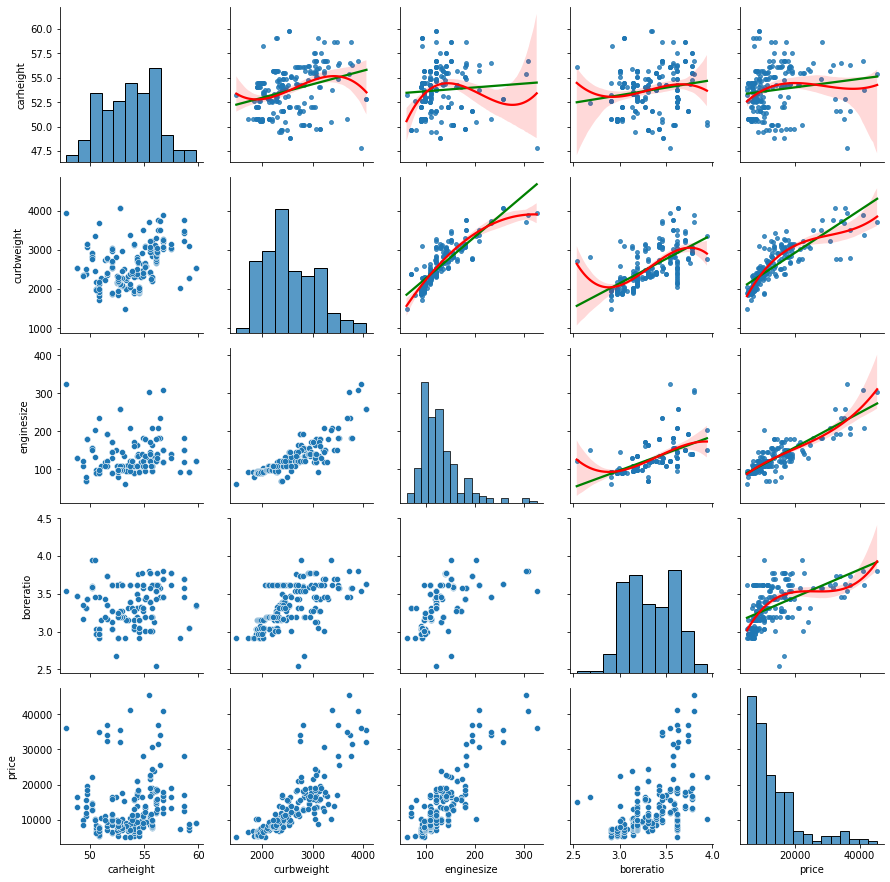

In [62]:
g=sns.PairGrid(data = df,vars = ['carheight','curbweight','enginesize','boreratio','price'])
g.map_upper(sns.regplot,ci=None, scatter_kws={'s':15}, line_kws={"color": "green"})
g.map_upper(sns.regplot,ci=90, line_kws={"color": "red"},order=3,scatter=False)
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)

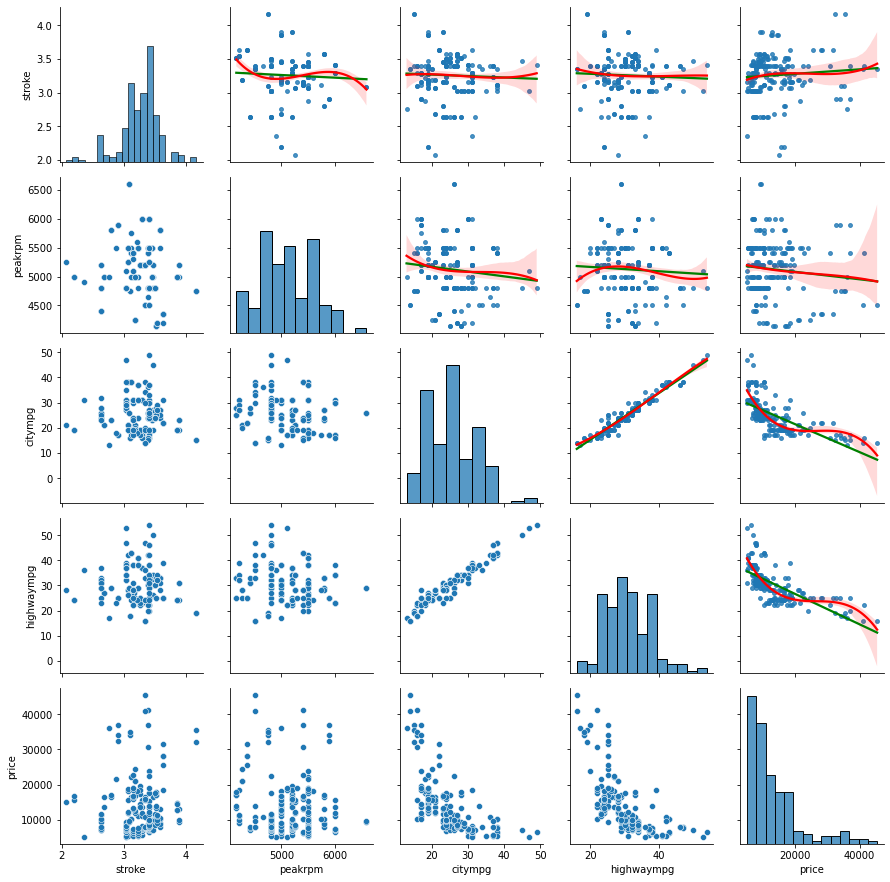

In [63]:
g=sns.PairGrid(data = df,vars = ['stroke','peakrpm','citympg','highwaympg','price'])
g.map_upper(sns.regplot,ci=None, scatter_kws={'s':15}, line_kws={"color": "green"})
g.map_upper(sns.regplot,ci=90, line_kws={"color": "red"},order=3,scatter=False)
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)

In [64]:
cat_cols=[]
for col in df.columns:
    if df[col].dtypes=='object':
        cat_cols.append(col)
cat_cols

['fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'enginetype',
 'cylindernumber',
 'fuelsystem']

Before we dig into performing model experiments. We will convert all the categorical columns in to OHE (one hot encoded vector) and drop the first columns to avoid the dummy trap. 

Writing the clean dataset to the output. 

In [65]:
df.to_csv('auto_clean_1985_dataset.csv',index=False)

In [66]:
df = pd.get_dummies(data = df,
               columns = cat_cols,
               drop_first =True,
              dtype='int8')
df.columns

Index(['symboling', 'normalized_losses', 'CarName', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio',
       'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg',
       'highwaympg', 'price', 'fueltype_gas', 'aspiration_turbo',
       'doornumber_two', 'carbody_hardtop', 'carbody_hatchback',
       'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd',
       'enginelocation_rear', 'enginetype_dohcv', 'enginetype_l',
       'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'cylindernumber_five', 'cylindernumber_four',
       'cylindernumber_six', 'cylindernumber_three', 'cylindernumber_twelve',
       'cylindernumber_two', 'fuelsystem_2bbl', 'fuelsystem_4bbl',
       'fuelsystem_idi', 'fuelsystem_mfi', 'fuelsystem_mpfi',
       'fuelsystem_spdi', 'fuelsystem_spfi'],
      dtype='object')

<AxesSubplot:>

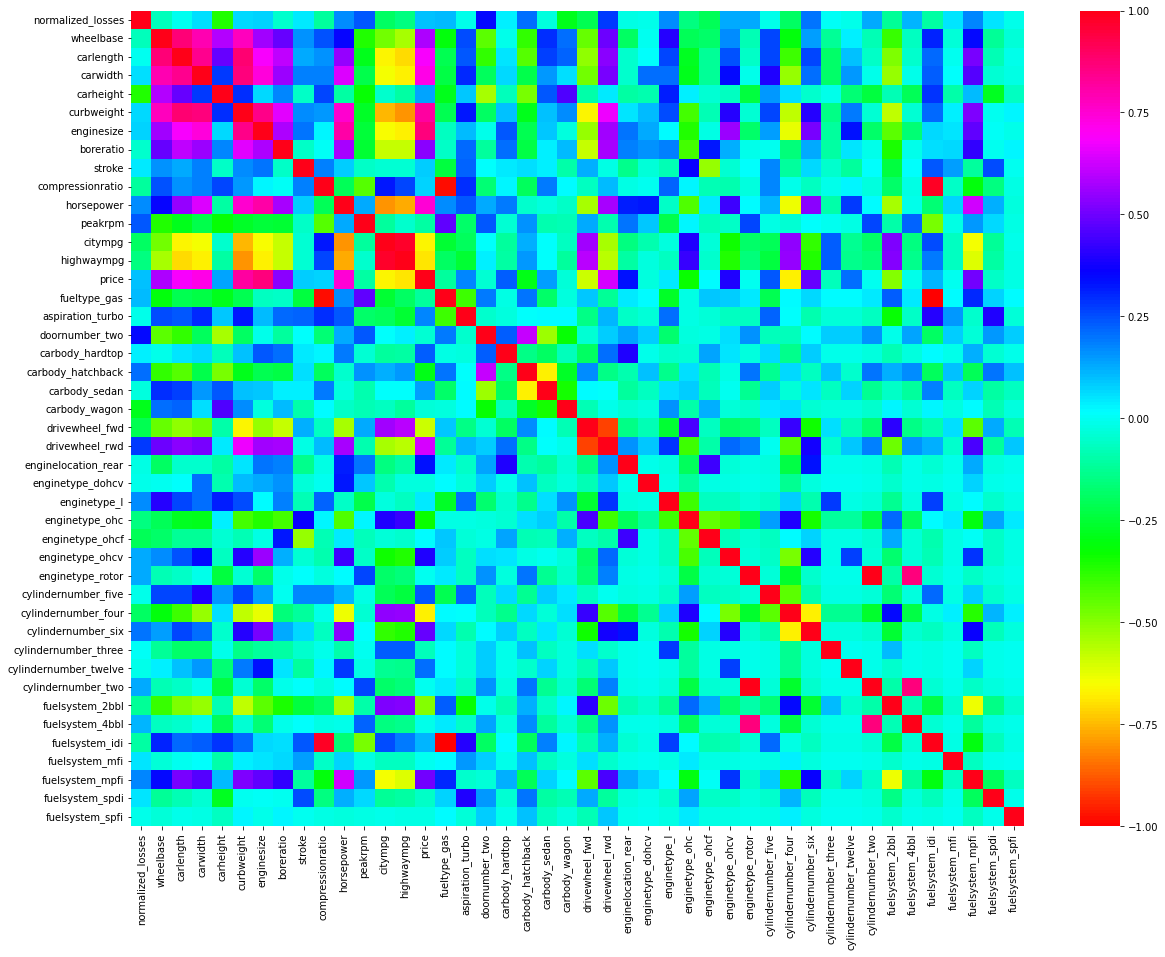

In [67]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap='hsv',annot=False)

The above figure represents the correlation between the numerical data columns and helps to select the appropriate column features with higher importance if needed.

In [68]:
df.dtypes

symboling                category
normalized_losses           int64
CarName                  category
wheelbase                 float64
carlength                 float64
carwidth                  float64
carheight                 float64
curbweight                  int64
enginesize                  int64
boreratio                 float64
stroke                    float64
compressionratio          float64
horsepower                  int64
peakrpm                     int64
citympg                     int64
highwaympg                  int64
price                       int64
fueltype_gas                 int8
aspiration_turbo             int8
doornumber_two               int8
carbody_hardtop              int8
carbody_hatchback            int8
carbody_sedan                int8
carbody_wagon                int8
drivewheel_fwd               int8
drivewheel_rwd               int8
enginelocation_rear          int8
enginetype_dohcv             int8
enginetype_l                 int8
enginetype_ohc

In [69]:
num_cols=[]
for col in df.columns:
    if df[col].dtypes=='int64' or df[col].dtypes=='float64':
        num_cols.append(col)
num_cols

['normalized_losses',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginesize',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price']

Transforming the numerical data columns with MinMaxScaler.

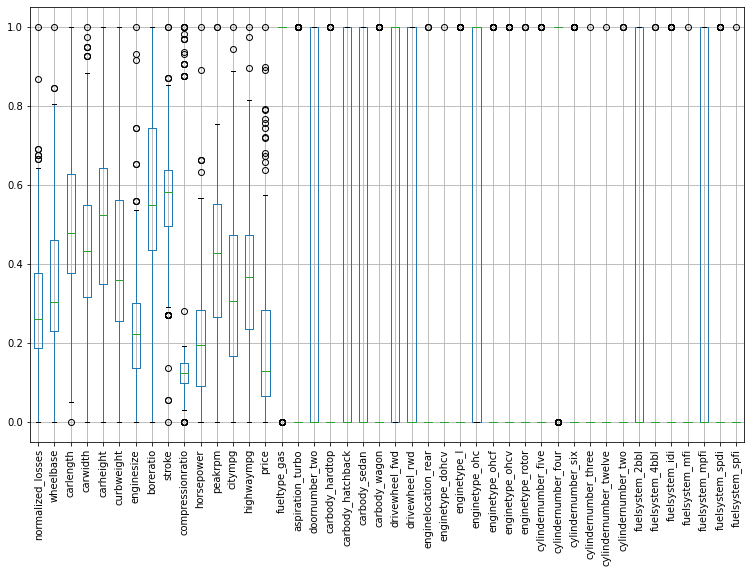

In [70]:

# first let convert the X in to minmax scaler and identify the outliers
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range =(0,1))

df[num_cols] = pd.DataFrame(sc.fit_transform(df[num_cols]))

df.boxplot(figsize = (12.8,8), rot = 90)
plt.boxplot
plt.show()

The above figure can be used to determine the outliers and help in removing the outliers if needed. 

In [71]:
df.head()

,symboling,normalized_losses,CarName,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,0.261780,alfa-romero,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,...,0,0,0,0,0,0,0,1,0,0
1,3,0.261780,alfa-romero,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,...,0,0,0,0,0,0,0,1,0,0
2,1,0.261780,alfa-romero,0.230321,0.449254,0.433333,0.383333,0.517843,0.343396,0.100000,...,0,0,0,0,0,0,0,1,0,0
3,2,0.518325,audi,0.384840,0.529851,0.491667,0.541667,0.329325,0.181132,0.464286,...,0,0,0,0,0,0,0,1,0,0
4,2,0.518325,audi,0.373178,0.529851,0.508333,0.541667,0.518231,0.283019,0.464286,...,0,0,0,0,0,0,0,1,0,0


In [72]:
X=df.drop(columns=['price','CarName'])

Without using the output label of 'price' column we will cluster the data to identify it into four types. 

In [73]:
X.head()

,symboling,normalized_losses,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,0.261780,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,0.290476,...,0,0,0,0,0,0,0,1,0,0
1,3,0.261780,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,0.290476,...,0,0,0,0,0,0,0,1,0,0
2,1,0.261780,0.230321,0.449254,0.433333,0.383333,0.517843,0.343396,0.100000,0.666667,...,0,0,0,0,0,0,0,1,0,0
3,2,0.518325,0.384840,0.529851,0.491667,0.541667,0.329325,0.181132,0.464286,0.633333,...,0,0,0,0,0,0,0,1,0,0
4,2,0.518325,0.373178,0.529851,0.508333,0.541667,0.518231,0.283019,0.464286,0.633333,...,0,0,0,0,0,0,0,1,0,0


# K-Means Cluster

Identifying the optimized number of clusters.

Text(0.5, 0, 'K_values')

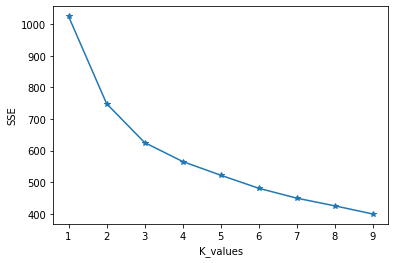

In [74]:
from sklearn.cluster import KMeans
k_rng = range(1,10)

sse1 = []

for k1 in k_rng:
    km1 = KMeans(n_clusters = k1)
    km1.fit(X)
    sse1.append(km1.inertia_)
    
plt.plot(k_rng,sse1,marker='*')
plt.ylabel('SSE')
plt.xticks(k_rng)
plt.xlabel('K_values')

We selected 4 as optimimum number of clusters.

In [75]:
km = KMeans(n_clusters = 4)
km.fit(X)
y_predict = km.predict(X)
df['cluster_Number']=y_predict

In [76]:
cluster_category = {0:'Budget',1:'Luxury',2:'Premium',3:'Economy'}

df['cluster'] = df['cluster_Number'].map(cluster_category)

We categorize the cluster values depending upon the price. 

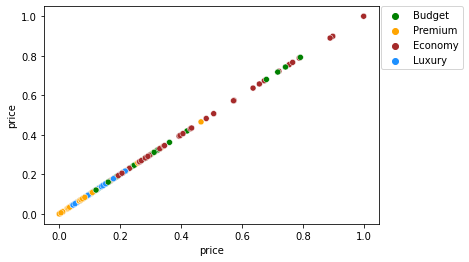

In [77]:
sns.scatterplot(data=df, x = "price", y="price",hue="cluster",palette=['green','orange','brown','dodgerblue'])
plt.legend(bbox_to_anchor=(1.25, 1),
           borderaxespad=0)

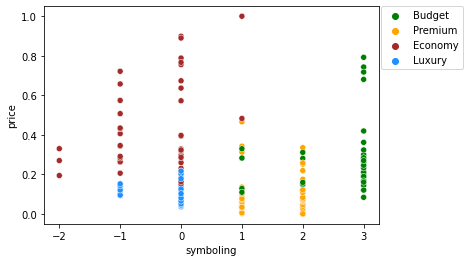

In [78]:
sns.scatterplot(data=df, x = "symboling", y="price",hue="cluster",palette=['green','orange','brown','dodgerblue'])
plt.legend(bbox_to_anchor=(1.25, 1),
           borderaxespad=0)